파일 세팅

In [ ]:
# 1. 저장소 통째로 가져오기
!git clone https://github.com/widetable/skku2006_ai_storytelling/data.git

# 2. 저장소 폴더 안으로 이동하기 (이게 핵심!)
%cd skku2006_ai_storytelling/data

# 3. 제대로 가져왔는지 파일 목록 확인 (선택사항)
!ls

한글 Font 설정

In [ ]:
import requests
from bs4 import BeautifulSoup as bs

In [ ]:
!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.font_manager as fm
sys_font = fm.findSystemFonts()

[f for f in sys_font if 'Nanum' in f]

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

['/usr/share/fonts/truetype/nanum/NanumMyeongjoEcoBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumMyeongjoEcoR.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicEcoBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquare_acEB.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicExtraBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf',
 '/usr/share/fonts/truetype/nanum/NanumBarunpenR.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareL.ttf',
 '/usr/share/fonts/truetype/nanum/NanumMyeongjoEco.ttf',
 '/usr/share/fonts/truetype/nanum/NanumPen.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicEcoR.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareRoundEB.ttf',
 '/usr/share/fonts/truetype/nanum/NanumMyeongjoExtraBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf',
 '/usr/share/fonts/truetype/nanum/NanumBarunGothicUltraLight.ttf',
 '/usr/share/fonts/

KONLPY 패키지 설치

In [ ]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 44.4 MB/s eta 0:00:00


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from konlpy.tag import Okt
from PIL import Image
import numpy as np

In [ ]:
# 파일 경로 수정
with open('대한민국헌법.txt', 'r', encoding='utf-8') as f:
    text = f.read()

okt = Okt()
nouns = okt.nouns(text)  # 명사만 추출

words = [n for n in nouns if len(n) > 1]  # 한 글자인 단어는 제외

c = Counter(words)  # 단어별 빈도수 계산
print(c.most_common(20))  # 상위 20개 출력


[('법률', 127), ('대통령', 83), ('국가', 73), ('국회', 68), ('국민', 61), ('헌법', 53), ('모든', 37), ('기타', 26), ('사항', 23), ('권리', 21), ('의원', 21), ('자유', 20), ('정부', 20), ('선거', 20), ('임명', 20), ('직무', 19), ('국무총리', 19), ('경제', 18), ('의무', 18), ('조직', 18)]


In [ ]:
# 한글 폰트 문제 해결
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

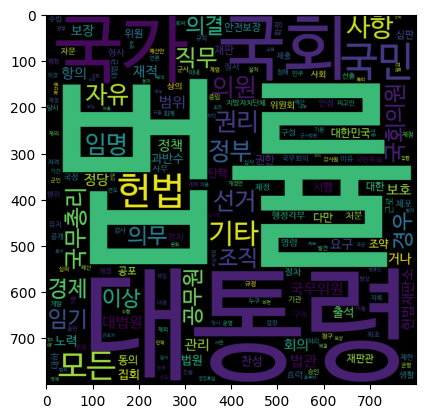

In [ ]:
wc = WordCloud(font_path=font_path, width=400, height=400, scale=2.0, max_font_size=250)
gen = wc.generate_from_frequencies(c)
plt.figure()
plt.imshow(gen)

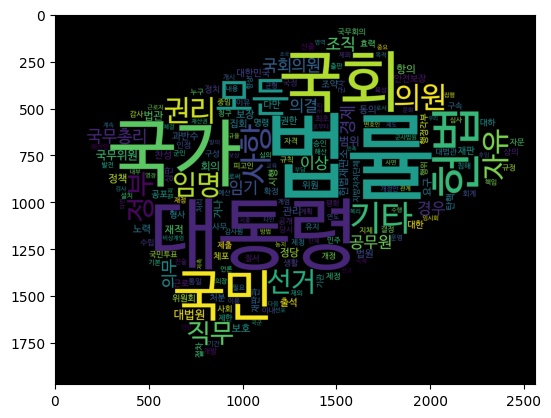

In [ ]:
img = Image.open('책_검은배경.jpg')
img_array = np.array(img)

wc = WordCloud(font_path=font_path, width=400, height=400, scale=2.0, max_font_size=250, mask=img_array)
gen = wc.generate_from_frequencies(c)

plt.figure()
plt.imshow(gen)

In [ ]:
wc.to_file('법전_워드클라우드2025.png')

# 기사를 크롤링하여 단어 빈도에 따른 워드클라우드를 만들어봅니다.

BTS와 군복무

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from konlpy.tag import Okt

In [ ]:
import requests
from bs4 import BeautifulSoup
from konlpy.tag import Okt
from collections import Counter

def get_naver_news(url):
    h = {'user-agent': 'Mozilla/5.0'}
    r = requests.get(url, headers=h, timeout=10)
    r.raise_for_status()
    bs = BeautifulSoup(r.text, 'html.parser')

    def pick_text(selectors):
        for sel in selectors:
            node = bs.select_one(sel)
            if node:
                txt = node.get_text(" ", strip=True)
                if txt:
                    return txt
        return None

    date   = pick_text(['span.media_end_head_info_datestamp_time'])
    title  = pick_text(['h2.media_end_head_headline', 'h3#articleTitle'])
    # 언론사명
    media_img = bs.select_one('a.media_end_head_top_logo img')
    media = media_img['alt'] if (media_img and media_img.has_attr('alt')) else None
    # 본문 후보 여러 개(모바일/PC/구형)
    content = pick_text(['#dic_area', '#newsct_article', '#articleBodyContents'])

    return {'date': date, 'title': title, 'media': media, 'content': content}

# 사용
url = "https://n.news.naver.com/mnews/article/081/0003270706?sid=103"
article = get_naver_news(url)

content = article['content']
if not content:
    raise ValueError("본문을 찾지 못했습니다. 네이버의 DOM 구조가 달라졌거나 이 기사 형식이 특수합니다.")

okt = Okt()
nouns = okt.nouns(content)                 # ← 이제 문자열 보장
words = [n for n in nouns if len(n) > 1]
c = Counter(words)
print(c.most_common(30))


[('병역', 20), ('특례', 15), ('방탄소년단', 9), ('예술인', 9), ('예술', 9), ('대중문화', 8), ('장관', 7), ('미국', 5), ('국회', 5), ('황희', 5), ('체육', 5), ('요원', 5), ('활동', 5), ('국위', 4), ('선양', 4), ('그룹', 4), ('연합뉴스', 4), ('혜택', 4), ('사람', 4), ('편입', 4), ('제도', 4), ('사회', 4), ('적용', 4), ('지난달', 4), ('콘서트', 4), ('소속사', 4), ('하이브', 4), ('검토', 4), ('최초', 3), ('시상식', 3)]


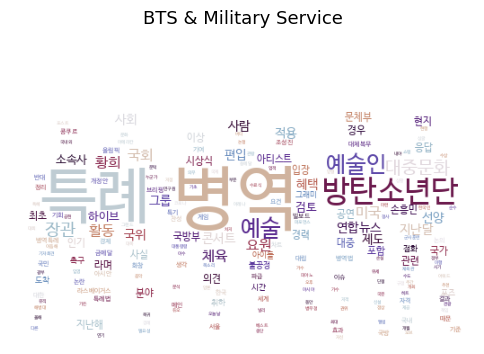

In [ ]:
from PIL import Image
import numpy as np

im = Image.open('BTS.jpg') # 이미지 파일 읽어오기
mask_arr = np.array(im) # 픽셀 값 배열 형태 변환

okt = Okt()
#nouns = okt.nouns(text)

wordcloud = WordCloud(background_color ='white', colormap='twilight_shifted',font_path=font_path,
                      width = 700, height = 700, random_state = 43, mask = mask_arr,
                      prefer_horizontal = True).generate_from_frequencies(c)


plt.figure(figsize = (6, 6))
plt.imshow(wordcloud)
plt.title('BTS & Military Service', size = 13)

plt.axis('off')

plt.show()

# 네이버 블로그 글에 대해서도 워드클라우드를 만들어봅니다.

In [ ]:
import requests
from bs4 import BeautifulSoup

def get_naver_blog(url) :
  h = {'user-agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/95.0.4638.69 Safari/537.36'}

  res = requests.get(url, headers = h)
  bs = BeautifulSoup(res.content, 'html.parser')

  new_url = 'https://blog.naver.com/' + bs.select('iframe')[0]['src']
  res = requests.get(new_url, headers = h)
  bs = BeautifulSoup(res.content, 'html.parser')

  date = bs.select('span.se_publishDate')[0].text
  title = bs.select('div.se-title-text p span')[0].text
  content = bs.select('div.se-main-container')[0].get_text().replace('\n','')

  return (date, title, content)


In [ ]:
url = "https://blog.naver.com/skybluewoogi/222635027511"

article = get_naver_blog(url)

In [ ]:
article[2]

'I. 사설 목록\u200b \u200bII. 주요 특징\u200b◆ “국가의 전면적 부흥과 발전”과 더불어“인민복리”담론을 강조하기 시작한 것은 담론체계 변화와 관련하여 주목할 대목(9.9)- 인민생활 향상을 국가발전의 하위 담론으로 설정했던 담론활용방식에서 탈피하여 국가 발전과 인민복리 담론을 분리함으로써 인민적 성격을 부각\u200b◆5개년계획 첫해의 연말결산 시점이 다가옴에 따른 성과달성의 조급성 표시(9.12)- 첫해 과업의 수행 여부가 최종목표 점령의 확신성을 보장할 뿐만 아니라 올해 사업계획을 당중앙위원회 8기 2차 전원회의에서 “실현가능한 목표”로 결정하였으므로 목표 수행 여부는 당의 정치적 권위와 직결된다는 정치적 부담 시사* “년말까지는 얼마 남지 않았다. 우리는 오늘의 하루하루를 열흘, 백날맞잡이로 압축하며 과감한 총돌격전을 벌려 올해 전투목표를 기어이 완수하여야 한다”\u200b◆ 시, 군 강화발전사업의 목적이 “시, 군들 자체로 인민생활문제를 풀어나가는 자립적인 시, 군으로의 전변”에 있음을 강조(9.14)- 당면한 삼중고 상황에서 중앙의 부담을 줄이기 위한 조치임에도 불구하고, “전국의 균형적 동시발전 촉진”을 통한 “국가의 전면적 부흥”, 즉 북한식 국가균형발전을 명분으로 제시* “시, 군 일군들이 당과 국가의 고민과 걱정을 자기 어깨우에 걸머지고 하나라도 풀기 위해 헌신분투하여야 할 때이다”\u200b◆ 노동신문 사설 제목에서 최초로 김정은을 “수령”으로 묘사(9.20)- 북한은 세 명 또는 두 명의 최고지도자를 병렬적으로 호칭할 때, 김일성은 ‘수령’, 김정일은 ‘영도자’ 또는 ‘장군님’, 김정은은 ‘영도자’ 또는 ‘원수님’으로 엄격히 구분하여 사용- 최고지도자를 특정하여 호칭할 때는 김정일과 김정은에게도 ‘수령’호칭 사용* “현시대의 가장 걸출한 수령이신 경애하는 총비서동지의 혁명전사된 크나큰 긍지와 자부심을 가슴뿌듯이 절감”- 김일성과 김정일을 통칭하여 ‘선대수령’또는 ‘위대한 수령님들’ 호칭을 사용함으로써 김정은이 현재 수령

In [ ]:
okt = Okt()
nouns = okt.nouns(article[2]) # 명사만 추출

words = [n for n in nouns if len(n) > 1] # 단어의 길이가 1개인 것은 제외

c = Counter(words) # 위에서 얻은 words를 처리하여 단어별 빈도수 형태의 딕셔너리 데이터를 구함

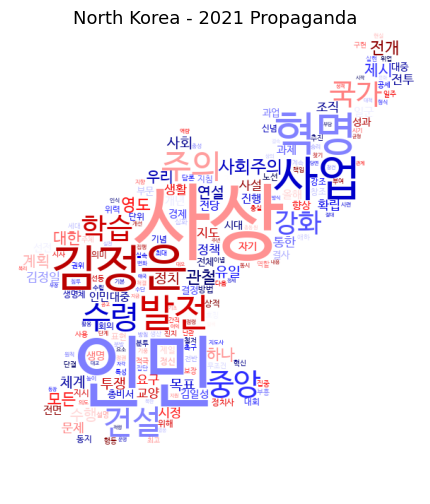

In [ ]:
from PIL import Image
import numpy as np

im = Image.open('북한지도.jpg') # 이미지 파일 읽어오기
mask_arr = np.array(im) # 픽셀 값 배열 형태 변환

#okt = Okt()
#nouns = okt.nouns(text)

wordcloud = WordCloud(background_color ='white', colormap='seismic',font_path=font_path,
                      width = 700, height = 700, random_state = 43, mask = mask_arr,
                      prefer_horizontal = True).generate_from_frequencies(c)


plt.figure(figsize = (6, 6))
plt.imshow(wordcloud)
plt.title("North Korea - 2021 Propaganda", size = 13)

plt.axis('off')

plt.show()

# 연습문제: 제21대 대통령 취임사를 당선자 이미지를 이용하여 워드 클라우드를 만들어봅니다.

In [ ]:
import requests
from bs4 import BeautifulSoup

h = {'user-agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/95.0.4638.69 Safari/537.36'}

res = requests.get(url, headers = h)
bs = BeautifulSoup(res.content, 'html.parser')

new_url = 'https://www.president.go.kr/president/speeches/ZgNcHbBx'
res = requests.get(new_url, headers = h)
bs = BeautifulSoup(res.content, 'html.parser')
txt_area = bs.select_one("div.view_txt div.txtArea").get_text().replace('\n','').replace('\xa0','')

In [ ]:
txt_area

'존경하고 사랑하는 국민 여러분,여러분이 선택해 주신 대한민국 제21대 대통령 이재명 인사드립니다.한없이 무거운 책임감과 한없이 뜨거운 감사함으로 이 자리에 섰습니다.5,200만 국민이 보내주신 5,200만 가지 열망과 소망을 품고오늘부터 저는 대한민국 21대 대통령으로서 진정한 민주공화국 대한민국을 향한 첫 발을 내딛습니다.미래가 우리를 향해 손짓하고 있습니다.벼랑 끝에 몰린 민생을 되살리고, 성장을 회복해 모두가 행복한 내일을 만들어갈 시간입니다.정쟁 수단으로 전락한 안보와 평화,무관심과 무능 무책임으로 무너진 민생과 경제,장갑차와 자동소총에 파괴된 민주주의를 다시 일으켜 세울 시간입니다.우리를 갈라놓은 혐오와 대결 위에 공존과 화해, 연대의 다리를 놓고, 꿈과 희망이 넘치는 국민행복 시대를 활짝 열어젖힐 시간입니다.한강 작가가 말한 대로, 과거가 현재를 돕고, 죽은 자가 산자를 구했습니다.이제는 우리가, 미래의 과거가 되어 내일의 후손들을 구할 차례입니다.국민 앞에 약속드립니다.깊고 큰 상처 위에 희망을 꽃피우라는 준엄한 명령과,완전히 새로운 나라를 만들라는 그 간절한 염원에 응답하겠습니다.이번 대선에서 누구를 지지했든 크게 통합하라는 대통령의 또 다른 의미에 따라,모든 국민을 아우르고 섬기는 ‘모두의 대통령’이 되겠습니다.대한민국은 오늘도 새로운 역사를 쓰고 있습니다.식민지에서 해방된 나라 가운데 유일하게 산업화와 민주화에 성공한 나라,세계 10위 경제력에 세계 5위의 막강한 군사력을 자랑하며K-컬처로 세계문화를 선도하는 나라.이 자랑스러운 동방의 한 나라가 이제는,맨손의 응원봉으로 최고 권력자의 군사쿠데타를 진압하는민주주의 세계사의 새 장을 열고 있습니다.대한민국의 이 위대한 여정을, 대한국민의 이 위대한 역량을 전 세계인이 경이로움으로 지켜보고 있습니다.오색 빛 혁명, K-민주주의는 위기에 처한 민주주의의 새 활로를 찾는 세계인들에게 뚜렷한 모범이 되었습니다.사랑하는 국민 여러분,우리는 지금 대전환의 분기점에 서 있습니다.낡은 질서가 퇴조하고 새 질

In [ ]:
okt = Okt()
nouns = okt.nouns(txt_area) # 명사만 추출

words = [n for n in nouns if len(n) > 1] # 단어의 길이가 1개인 것은 제외

c = Counter(words) # 위에서 얻은 words를 처리하여 단어별 빈도수 형태의 딕셔너리 데이터를 구함

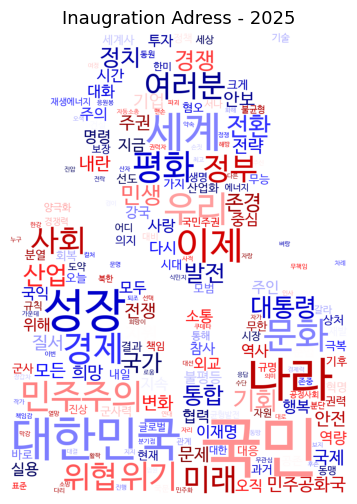

In [ ]:
from PIL import Image
import numpy as np

im = Image.open('취임식실루엣.png') # 이미지 파일 읽어오기
mask_arr = np.array(im) # 픽셀 값 배열 형태 변환

#okt = Okt()
#nouns = okt.nouns(text)

wordcloud = WordCloud(background_color ='white', colormap='seismic',font_path=font_path,
                      width = 700, height = 700, random_state = 43, mask = mask_arr,
                      prefer_horizontal = True).generate_from_frequencies(c)


plt.figure(figsize = (6, 6))
plt.imshow(wordcloud)
plt.title("Inaugration Adress - 2025", size = 13)

plt.axis('off')

plt.show()